In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def gerar_grafico_conformal(csv_auditado):
    # 1. Carregar os dados (usando os escores agregados s_doc do MACI)
    df = pd.read_csv(csv_auditado)
    
    # Se o CSV for o de sentenças, precisamos agrupar antes
    if 's_doc' not in df.columns:
        df['prob_fiel'] = 1 - df['non_conformity_score']
        df = df.groupby('id_bo')['prob_fiel'].prod().reset_index()
        df['s_doc'] = 1 - df['prob_fiel']

    scores = df['s_doc'].values
    n = len(scores)
    
    # 2. Simular diferentes níveis de alpha
    alphas = np.linspace(0.01, 0.20, 20) # De 1% a 20% de erro
    retencao = []
    erro_real = []

    for a in alphas:
        # Cálculo do limiar q_hat para cada alpha
        q_level = np.ceil((n + 1) * (1 - a)) / (n + 1)
        q_hat = pd.Series(scores).quantile(q_level, interpolation='higher')
        
        # Filtro guardrail
        aprovados = scores <= q_hat
        retencao.append(np.mean(aprovados) * 100)
        
        # Erro residual médio nos aprovados
        if np.any(aprovados):
            erro_real.append(np.mean(scores[aprovados]) * 100)
        else:
            erro_real.append(0)

    # 3. Plotagem do Gráfico
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Nível de Significância Alpha (Tolerância ao Erro)')
    ax1.set_ylabel('Taxa de Retenção de Relatórios (%)', color=color)
    ax1.plot(alphas, retencao, marker='o', color=color, label='Retenção (Utilidade)')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Risco de Alucinação Residual (%)', color=color)
    ax2.plot(alphas, erro_real, marker='s', color=color, label='Erro Residual (Risco)')
    ax2.tick_params(axis='y', labelcolor=color)

    # Destaque para o ponto atual (0.36 / 7.27%)
    plt.title('Framework MACI: Equilíbrio entre Segurança Jurídica e Automação\n(Dataset Policial Brasileiro)', fontsize=14)
    fig.tight_layout()
    plt.savefig('curva_conformal_seguranca.png', dpi=300)
    plt.show()

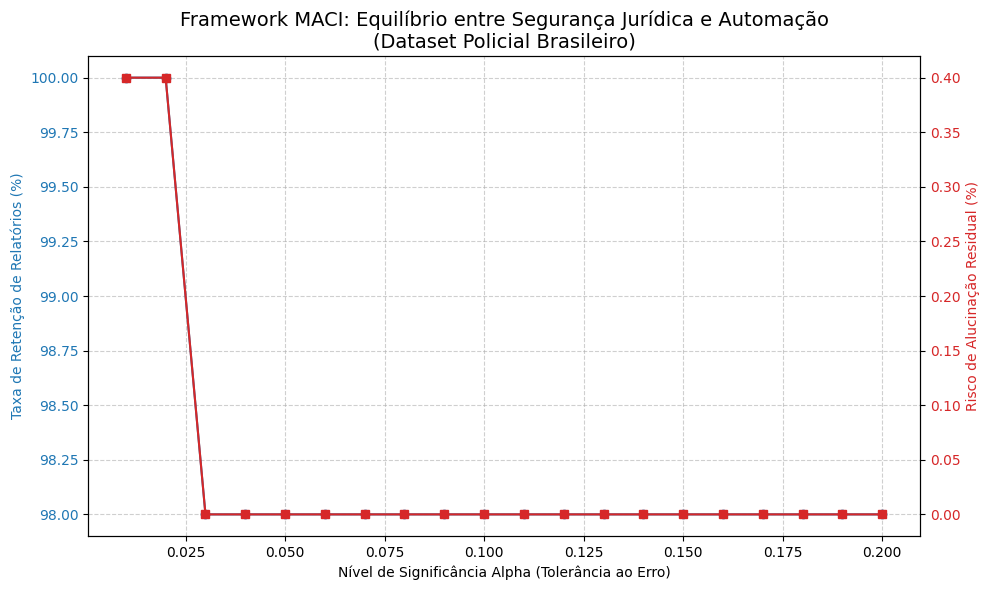

In [4]:
gerar_grafico_conformal("sentencas_auditadas_votos.csv")